In [1]:
from google.colab import files

uploaded = files.upload()

Saving SalmonScan.zip to SalmonScan (1).zip


In [2]:
# Extract the ZIP file
import zipfile
import os

zip_path = "/content/SalmonScan (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os

print(os.listdir("/content/dataset"))

['SalmonScan']


In [4]:
import os

print(os.listdir("/content"))

['.config', 'dataset', 'SalmonScan (1).zip', 'SalmonScan.zip', 'sample_data']


In [5]:
dataset= "/content/SalmonScan"

In [6]:
print(os.listdir("/content/dataset/SalmonScan"))

['Raw', 'Augmented']


In [7]:
print(os.listdir("/content/dataset/SalmonScan"))

['Raw', 'Augmented']


In [8]:
import os

print(os.listdir("/content/dataset/SalmonScan/Augmented"))

['FreshFish', 'InfectedFish']


In [9]:
import os

print(os.listdir("/content"))
print(os.listdir("/content/dataset"))

['.config', 'dataset', 'SalmonScan (1).zip', 'SalmonScan.zip', 'sample_data']
['SalmonScan']


In [10]:
dataset_path = "/content/SalmonScan"

In [11]:
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split

fresh_path = '/content/dataset/SalmonScan/Augmented/FreshFish'
infected_path = '/content/dataset/SalmonScan/Augmented/InfectedFish'

In [12]:
import random
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
import os

data_dir = "/content/dataset/SalmonScan/Augmented"

print("Exists:", os.path.exists(data_dir))
print("Folders:", os.listdir(data_dir))

Exists: True
Folders: ['FreshFish', 'InfectedFish']


In [22]:
data_dir = "/content/dataset/SalmonScan/Augmented"

class_names = sorted(os.listdir(data_dir))

all_paths = []
all_labels = []

for label, class_name in enumerate(class_names):
    class_dir = os.path.join(data_dir, class_name)

    for image in os.listdir(class_dir):
        image_path = os.path.join(class_dir, image)
        all_paths.append(image_path)
        all_labels.append(label)

In [23]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
import os

# Train/Test Split
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)

# Image preprocessing
def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [250,250])
    img = img / 255.0
    return img, label

# Train Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_dataset = train_dataset.map(load_and_preprocess_image)
train_dataset = train_dataset.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

# Test Dataset
test_dataset = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_dataset = test_dataset.map(load_and_preprocess_image)
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

CLASS WEIGHT

In [24]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)


Class weights: {0: np.float64(1.3232876712328767), 1: np.float64(0.8036605657237936)}


In [27]:
IMG_HEIGHT = 250
IMG_WIDTH = 250

# **CNN**

In [28]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.15),
], name="data_augmentation")

inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = data_augmentation(inputs)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2, 2)(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2, 2)(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2, 2)(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs, name="fish_cnn")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
    ]
)

model.summary()


Model: "fish_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 250, 250, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 250, 250, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 125, 125, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 62, 62, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

CALLBACKS

In [29]:
import tensorflow as tf

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [30]:
callbacks = [early_stopping]

In [31]:
EPOCHS = 40  # EarlyStopping will typically stop well before this

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


Epoch 1/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - accuracy: 0.8468 - auc: 0.8997 - loss: 0.3800 - precision: 0.8820 - recall: 0.8702 - val_accuracy: 0.3802 - val_auc: 0.8683 - val_loss: 1.0195 - val_precision: 1.0000 - val_recall: 0.0066
Epoch 2/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 185ms/step - accuracy: 0.8768 - auc: 0.9198 - loss: 0.3344 - precision: 0.8912 - recall: 0.9135 - val_accuracy: 0.3884 - val_auc: 0.8827 - val_loss: 1.0827 - val_precision: 1.0000 - val_recall: 0.0199
Epoch 3/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - accuracy: 0.8954 - auc: 0.9385 - loss: 0.2990 - precision: 0.8968 - recall: 0.9401 - val_accuracy: 0.6901 - val_auc: 0.8836 - val_loss: 0.5725 - val_precision: 0.8958 - val_recall: 0.5695
Epoch 4/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step - accuracy: 0.8861 - auc: 0.9357 - loss: 0.3106 - precision: 0.8903 - recall: 0.9318 - val_accuracy: 0.5041 - val_auc: 0.8837 - val_loss: 0.7694 - val_precision: 0.9189 - val_recall: 0.2252
Epoch 5/40
31/31 ━━━━━━━━━━━━━━

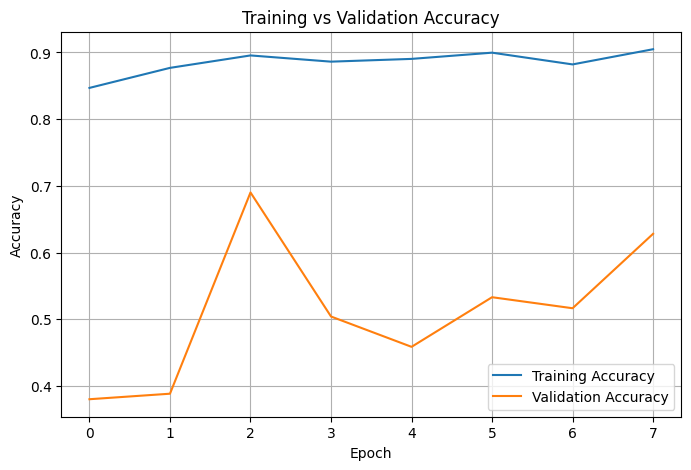

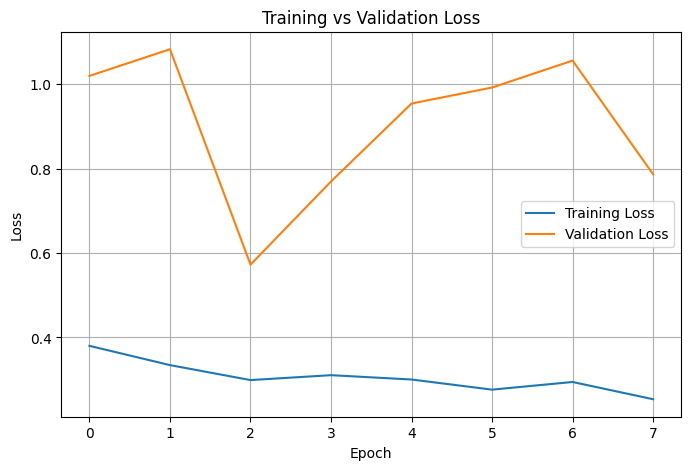

In [33]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Classification Report:

              precision    recall  f1-score   support

       Fresh       0.55      0.89      0.68        91
    Infected       0.90      0.57      0.70       151

    accuracy                           0.69       242
   macro avg       0.73      0.73      0.69       242
weighted avg       0.77      0.69      0.69       242

Confusion Matrix:

[[81 10]
 [65 86]]


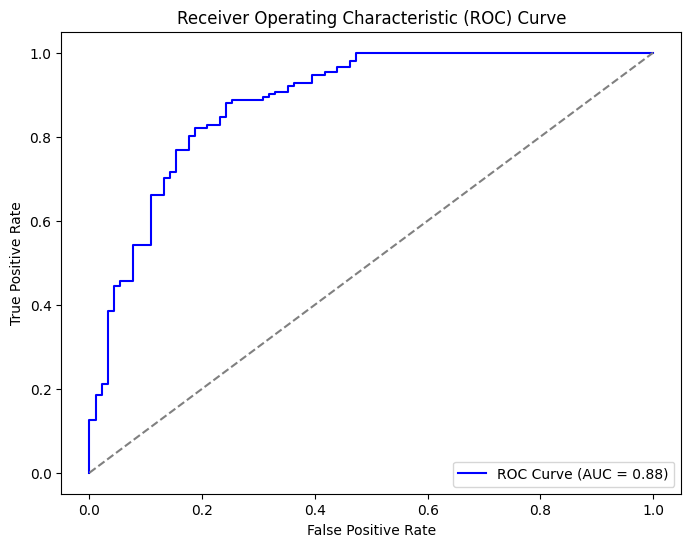

In [37]:
import numpy as np

y_true = []
y_pred = []
for images, labels in test_dataset:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

# Convert predictions to binary (0 or 1) based on threshold
y_pred_binary = [1 if pred > 0.5 else 0 for pred in y_pred]

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred_binary, target_names=['Fresh', 'Infected']))

# Confusion Matrix
print("Confusion Matrix:\n")
conf_matrix = confusion_matrix(y_true, y_pred_binary)
print(conf_matrix)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


# **VGG16**

In [60]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

In [62]:
IMG_HEIGHT = 224
IMG_WIDTH = 224

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

base_model.trainable = False

In [70]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(250, 600, 3)),          # Take original shape
    layers.Resizing(224, 224), # Resize to model backbone requirements
    # ... rest of your model layers / pre-trained backbone ...
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [72]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.AUC()
    ]
)

In [73]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [74]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [50]:
print(type(train_dataset))
print(type(test_dataset))
print(class_weight_dict)

<class 'tensorflow.python.data.ops.batch_op._BatchDataset'>
<class 'tensorflow.python.data.ops.batch_op._BatchDataset'>
{0: np.float64(1.3232876712328767), 1: np.float64(0.8036605657237936)}


In [75]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 42s 773ms/step - accuracy: 0.5041 - auc_2: 0.5524 - loss: 0.7115 - precision_2: 0.6565 - recall_2: 0.4286 - val_accuracy: 0.7645 - val_auc_2: 0.8244 - val_loss: 0.6458 - val_precision_2: 0.8392 - val_recall_2: 0.7792 - learning_rate: 1.0000e-04
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 16s 344ms/step - accuracy: 0.6170 - auc_2: 0.6335 - loss: 0.6663 - precision_2: 0.7311 - recall_2: 0.6207 - val_accuracy: 0.7521 - val_auc_2: 0.8601 - val_loss: 0.6224 - val_precision_2: 0.8730 - val_recall_2: 0.7143 - learning_rate: 1.0000e-04
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 333ms/step - accuracy: 0.6522 - auc_2: 0.7127 - loss: 0.6307 - precision_2: 0.7982 - recall_2: 0.5839 - val_accuracy: 0.8388 - val_auc_2: 0.8994 - val_loss: 0.5824 - val_precision_2: 0.8897 - val_recall_2: 0.8487 - learning_rate: 1.0000e-04
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 303ms/step - accuracy: 0.6781 - auc_2: 0.7306 - loss: 0.6129 - precision_2: 0.7660 - recall_2: 0.6960 - val_a

# **Fine** **Tuning**

In [76]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

In [77]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.AUC()
    ]
)

In [78]:
history_finetune = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 28s 570ms/step - accuracy: 0.8571 - auc_3: 0.9210 - loss: 0.3772 - precision_3: 0.8986 - recall_3: 0.8688 - val_accuracy: 0.9380 - val_auc_3: 0.9513 - val_loss: 0.2735 - val_precision_3: 0.9357 - val_recall_3: 0.9756 - learning_rate: 1.0000e-05
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 30s 378ms/step - accuracy: 0.9048 - auc_3: 0.9489 - loss: 0.2805 - precision_3: 0.9176 - recall_3: 0.9327 - val_accuracy: 0.9215 - val_auc_3: 0.9562 - val_loss: 0.2436 - val_precision_3: 0.9038 - val_recall_3: 0.9724 - learning_rate: 1.0000e-05
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 403ms/step - accuracy: 0.9172 - auc_3: 0.9501 - loss: 0.2657 - precision_3: 0.9203 - recall_3: 0.9481 - val_accuracy: 0.9421 - val_auc_3: 0.9791 - val_loss: 0.1891 - val_precision_3: 0.9363 - val_recall_3: 0.9735 - learning_rate: 1.0000e-05
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 385ms/step - accuracy: 0.9389 - auc_3: 0.9663 - loss: 0.2156 - precision_3: 0.9359 - recall_3: 0.9685 - val_a

## DENSE **NET**

In [38]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os


In [39]:
fresh_path  = '/content/dataset/SalmonScan/Augmented/FreshFish'
infected_path = '/content/dataset/SalmonScan/Augmented/InfectedFish'

def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [250, 600])
    img = img / 255.0
    return img, label

fresh_paths = [os.path.join(fresh_path, f) for f in os.listdir(fresh_path)]
infected_paths = [os.path.join(infected_path, f) for f in os.listdir(infected_path)]

fresh_labels = [0] * len(fresh_paths)
infected_labels = [1] * len(infected_paths)

all_paths = fresh_paths + infected_paths
all_labels = fresh_labels + infected_labels

dataset = tf.data.Dataset.from_tensor_slices((all_paths, all_labels))
dataset = dataset.map(lambda x, y: load_and_preprocess_image(x, y))

dataset = dataset.shuffle(buffer_size=1000)
train_size = int(0.8 * len(all_paths))
train_dataset = dataset.take(train_size).batch(32)
test_dataset = dataset.skip(train_size).batch(32)

def dense_block(x, growth_rate):
    bn = layers.BatchNormalization()(x)
    relu = layers.Activation('relu')(bn)
    conv = layers.Conv2D(growth_rate, (3, 3), padding='same')(relu)
    return layers.Concatenate()([x, conv])

inputs = layers.Input(shape=(250, 600, 3))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2, 2))(x)

x = dense_block(x, growth_rate=32)
x = layers.MaxPooling2D((2, 2))(x)

x = dense_block(x, growth_rate=32)
x = layers.MaxPooling2D((2, 2))(x)

x = dense_block(x, growth_rate=32)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)  # Binary classification

model1= models.Model(inputs, outputs)

model1.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 250, 600,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 250, 600,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 125, 300,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 300,  │        128 │ max_pooling2d_3[… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 125, 300,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 125, 300,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 125, 300,  │          0 │ max_pooling2d_3[… │
│ (Concatenate)       │ 64)               │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 62, 150,   │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 62, 150,   │        256 │ max_pooling2d_4[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 62, 150,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 62, 150,   │     18,464 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 62, 150,   │          0 │ max_pooling2d_4[… │
│ (Concatenate)       │ 96)               │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 31, 75,    │          0 │ concatenate_1[0]… │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 75,    │        384 │ max_pooling2d_5[… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 31, 75,    │          0 │ batch_normalizat… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 31, 75,    │     27,680 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 31, 75,    │          0 │ max_pooling2d_5[

 Total params: 73,697 (287.88 KB)

 Trainable params: 73,313 (286.38 KB)

 Non-trainable params: 384 (1.50 KB)

In [81]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [82]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 371ms/step - accuracy: 0.9648 - auc_3: 0.9910 - loss: 0.1287 - precision_3: 0.9628 - recall_3: 0.9819 - val_accuracy: 0.9463 - val_auc_3: 0.9911 - val_loss: 0.1362 - val_precision_3: 0.9281 - val_recall_3: 0.9861 - learning_rate: 2.0000e-06
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9509 - auc_3: 0.9859 - loss: 0.1439 - precision_3: 0.9536 - recall_3: 0.9683
Epoch 2: ReduceLROnPlateau reducing learning rate to 1e-06.
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 392ms/step - accuracy: 0.9576 - auc_3: 0.9883 - loss: 0.1364 - precision_3: 0.9583 - recall_3: 0.9755 - val_accuracy: 0.9587 - val_auc_3: 0.9939 - val_loss: 0.1149 - val_precision_3: 0.9419 - val_recall_3: 0.9932 - learning_rate: 2.0000e-06
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 394ms/step - accuracy: 0.9513 - auc_3: 0.9860 - loss: 0.1450 - precision_3: 0.9527 - recall_3: 0.9701 - val_accuracy: 0.9711 - val_auc_3: 0.9938 - val_loss: 0.1034 - val_precision_3: 0.9750 - val_reca

In [83]:
test_loss, test_accuracy = model1.evaluate(test_dataset)
print(f"Test Accuracy: {test_accuracy}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.8182 - loss: 0.4184
Test Accuracy: 0.8181818127632141


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.8678 - loss: 0.3981
Test Loss (DenseNet): 0.3981424868106842
Test Accuracy (DenseNet): 0.8677685856819153
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 883ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 868ms/step

Classification Report (DenseNet):
              precision    recall  f1-score   support

       Fresh       0.76      0.71      0.73        92
    Infected       0.83      0.87      0.85       150

    accuracy                           0.81       242
   macro avg       0.80      0.79      0.79       242
weighted avg       0.80      0.81      0.80       242


Confusion Matrix (DenseNet):
[[ 65  27]
 [ 20 130]]


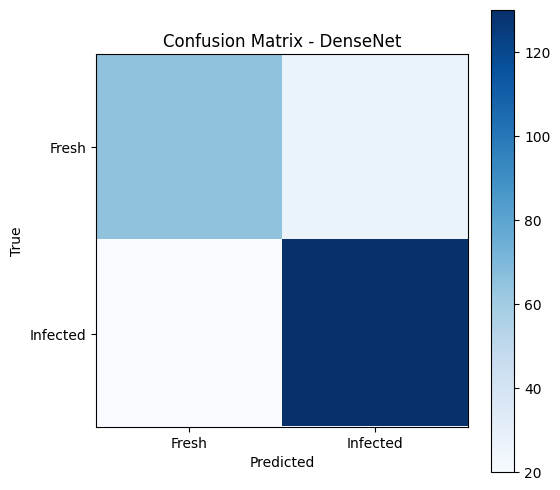

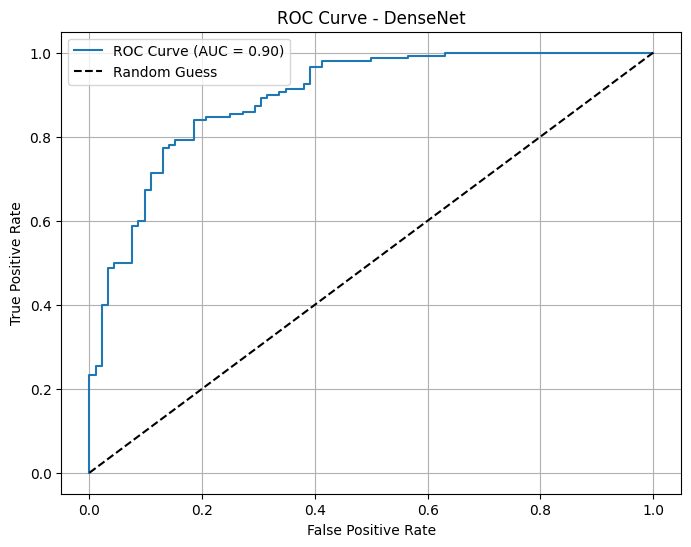

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

test_loss, test_accuracy = model1.evaluate(test_dataset)
print(f"Test Loss (DenseNet): {test_loss}")
print(f"Test Accuracy (DenseNet): {test_accuracy}")

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model1.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

y_pred_binary = [1 if pred > 0.5 else 0 for pred in y_pred]
print("\nClassification Report (DenseNet):")
print(classification_report(y_true, y_pred_binary, target_names=["Fresh", "Infected"]))

conf_matrix = confusion_matrix(y_true, y_pred_binary)
print("\nConfusion Matrix (DenseNet):")
print(conf_matrix)

plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, cmap="Blues", interpolation="nearest")
plt.title("Confusion Matrix - DenseNet")
plt.colorbar()
plt.xticks([0, 1], ["Fresh", "Infected"])
plt.yticks([0, 1], ["Fresh", "Infected"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("ROC Curve - DenseNet")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()